In [2]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import datetime

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# Load our clean parquet files

df_routes = pd.read_parquet('cleaned_data/clean_routes.parquet')
df_loads = pd.read_parquet('cleaned_data/clean_loads.parquet')
df_trips = pd.read_parquet('cleaned_data/clean_trips.parquet')
df_fuel_pur = pd.read_parquet('cleaned_data/clean_fuel_pur.parquet')

In [14]:
df_loads

,load_id,customer_id,route_id,load_date,load_type,weight_lbs,pieces,revenue,fuel_surcharge,accessorial_charges,load_status,booking_type
0,LOAD00000001,CUST00183,RTE00019,2022-01-01,Dry Van,19178,13,3045.23,406.72,100,Completed,Spot
1,LOAD00000002,CUST00076,RTE00058,2022-01-01,Dry Van,27761,22,1224.48,98.61,0,Completed,Dedicated
2,LOAD00000003,CUST00027,RTE00048,2022-01-01,Refrigerated,35594,16,7171.12,792.88,0,Completed,Spot
3,LOAD00000004,CUST00088,RTE00013,2022-01-01,Refrigerated,33274,10,1308.20,141.33,50,Completed,Spot
4,LOAD00000005,CUST00185,RTE00020,2022-01-01,Dry Van,40257,10,3317.18,738.48,0,Completed,Spot
...,...,...,...,...,...,...,...,...,...,...,...,...
85405,LOAD00085406,CUST00016,RTE00039,2024-12-31,Refrigerated,20353,20,2073.08,344.52,0,Completed,Dedicated
85406,LOAD00085407,CUST00179,RTE00008,2024-12-31,Dry Van,23061,11,2018.31,114.30,0,Completed,Contract
85407,LOAD00085408,CUST00136,RTE00056,2024-12-31,Refrigerated,12570,15,3952.46,309.24,200,Completed,Contract
85408,LOAD00085409,CUST00012,RTE00016,2024-12-31,Refrigerated,34121,7,6296.47,463.93,75,Completed,Dedicated


In [15]:
df_routes

,route_id,origin_city,origin_state,destination_city,destination_state,typical_distance_miles,base_rate_per_mile,fuel_surcharge_rate,typical_transit_days
0,RTE00001,Atlanta,Georgia,Chicago,Illinois,677,1.70,0.19,1
1,RTE00002,Atlanta,Georgia,Miami,Florida,697,2.08,0.22,1
2,RTE00003,Chicago,Illinois,Los Angeles,California,2003,2.55,0.29,3
3,RTE00004,Chicago,Illinois,Portland,Oregon,2017,1.84,0.19,3
4,RTE00005,Chicago,Illinois,Las Vegas,Nevada,1749,2.41,0.26,3
5,RTE00006,Chicago,Illinois,Charlotte,North Carolina,675,2.13,0.28,1
6,RTE00007,Dallas,Texas,New York,New York,1576,2.54,0.32,2
7,RTE00008,Dallas,Texas,Denver,Colorado,762,2.62,0.15,1
8,RTE00009,Dallas,Texas,Indianapolis,Indiana,878,1.95,0.17,1
9,RTE00010,New York,New York,Philadelphia,Pennsylvania,92,1.61,0.17,1


In [7]:
df_fuel_pur.head(20)

,fuel_purchase_id,trip_id,truck_id,driver_id,purchase_date,location_city,location_state,gallons,price_per_gallon,total_cost,fuel_card_number
0,FUEL00000001,TRIP00051284,TRK00045,DRV00102,2023-10-22 05:00:00,Columbus,MN,131.6,3.399,447.31,FC567161
1,FUEL00000002,TRIP00073723,TRK00013,Unknown,2024-08-04 08:00:00,New York,AZ,139.9,3.180,444.88,FC717910
2,FUEL00000003,TRIP00018286,TRK00024,DRV00142,2022-08-23 13:00:00,Seattle,NE,189.3,3.804,720.10,FC912816
3,FUEL00000004,TRIP00008465,TRK00018,DRV00047,2022-04-20 00:00:00,Memphis,NY,130.7,3.579,467.78,FC776357
4,FUEL00000005,TRIP00069700,TRK00054,Unknown,2024-06-13 09:00:00,Columbus,AZ,185.3,3.422,634.10,FC391024
5,FUEL00000006,TRIP00062650,TRK00012,DRV00104,2024-03-18 23:00:00,Dallas,NY,182.2,3.494,636.61,FC277504
6,FUEL00000007,TRIP00000851,TRK00072,DRV00127,2022-01-11 21:00:00,Miami,TX,146.3,3.914,572.62,FC256663
7,FUEL00000008,TRIP00012033,TRK00073,DRV00084,2022-06-06 00:00:00,Phoenix,PA,113.3,4.471,506.56,FC543608
8,FUEL00000009,TRIP00023596,TRK00101,DRV00080,2022-10-28 02:00:00,Miami,NC,127.0,4.445,564.51,FC484857
9,FUEL00000010,TRIP00037859,TRK00085,DRV00002,2023-04-30 09:00:00,Dallas,MO,134.7,3.357,452.19,FC753360


In [11]:
df_trips.head(20)

,trip_id,load_id,driver_id,truck_id,trailer_id,dispatch_date,actual_distance_miles,actual_duration_hours,fuel_gallons_used,average_mpg,idle_time_hours,trip_status
0,TRIP00000001,LOAD00000001,DRV00117,TRK00035,TRL00167,2022-01-01,1314,26.2,183.8,7.15,3.5,Completed
1,TRIP00000002,LOAD00000002,DRV00141,TRK00108,TRL00082,2022-01-01,515,8.6,93.6,5.50,8.3,Completed
2,TRIP00000003,LOAD00000003,DRV00032,TRK00031,TRL00138,2022-01-01,2509,45.0,339.1,7.40,12.0,Completed
3,TRIP00000004,LOAD00000004,DRV00083,TRK00105,TRL00018,2022-01-01,717,11.1,110.3,6.50,9.6,Completed
4,TRIP00000005,LOAD00000005,DRV00044,TRK00076,TRL00054,2022-01-01,2243,35.0,328.9,6.82,11.6,Completed
5,TRIP00000006,LOAD00000006,DRV00120,TRK00062,TRL00007,2022-01-01,1977,39.4,358.8,5.51,6.6,Completed
6,TRIP00000007,LOAD00000007,DRV00055,TRK00002,TRL00093,2022-01-01,1350,20.9,230.8,5.85,2.3,Completed
7,TRIP00000008,LOAD00000008,DRV00065,TRK00035,TRL00148,2022-01-01,2748,50.5,437.6,6.28,10.5,Completed
8,TRIP00000009,LOAD00000009,DRV00129,TRK00014,TRL00083,2022-01-01,3226,51.4,465.5,6.93,4.1,Completed
9,TRIP00000010,LOAD00000010,DRV00029,TRK00116,TRL00126,2022-01-01,3388,60.2,460.3,7.36,5.7,Completed


In [13]:
df_trips['trip_id'].nunique ()

85410

In [9]:
df_fuel_pur['trip_id'].nunique()

76939

In [10]:
df_fuel_pur.shape

(196442, 11)

In [21]:
# Aggregate Fuel Purchase data to the TRIP level

trip_fuel_summary = df_fuel_pur.groupby('trip_id').agg(
    actual_fuel_cost=('total_cost', 'sum'),
    fuel_gallons_bought=('gallons', 'sum')
).reset_index()

# Merge Fuel summaries into the Trips table

df_trips_with_fuel = df_trips.merge(trip_fuel_summary, on='trip_id', how='left').fillna(0)

# Aggregate Trip & Revenue data to the LOAD level
# (Since trips -> loads is 1-to-1, we compile costs per load)

load_financials = df_loads.merge(
    df_trips_with_fuel[['load_id', 'actual_distance_miles', 'actual_duration_hours', 'actual_fuel_cost']], 
    on='load_id', 
    how='left'
)

In [18]:
load_financials

,load_id,customer_id,route_id,load_date,load_type,weight_lbs,pieces,revenue,fuel_surcharge,accessorial_charges,load_status,booking_type,actual_distance_miles,actual_duration_hours,actual_fuel_cost
0,LOAD00000001,CUST00183,RTE00019,2022-01-01,Dry Van,19178,13,3045.23,406.72,100,Completed,Spot,1314,26.2,779.45
1,LOAD00000002,CUST00076,RTE00058,2022-01-01,Dry Van,27761,22,1224.48,98.61,0,Completed,Dedicated,515,8.6,752.70
2,LOAD00000003,CUST00027,RTE00048,2022-01-01,Refrigerated,35594,16,7171.12,792.88,0,Completed,Spot,2509,45.0,3796.39
3,LOAD00000004,CUST00088,RTE00013,2022-01-01,Refrigerated,33274,10,1308.20,141.33,50,Completed,Spot,717,11.1,0.00
4,LOAD00000005,CUST00185,RTE00020,2022-01-01,Dry Van,40257,10,3317.18,738.48,0,Completed,Spot,2243,35.0,512.53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85405,LOAD00085406,CUST00016,RTE00039,2024-12-31,Refrigerated,20353,20,2073.08,344.52,0,Completed,Dedicated,1023,19.2,1018.57
85406,LOAD00085407,CUST00179,RTE00008,2024-12-31,Dry Van,23061,11,2018.31,114.30,0,Completed,Contract,749,14.9,642.33
85407,LOAD00085408,CUST00136,RTE00056,2024-12-31,Refrigerated,12570,15,3952.46,309.24,200,Completed,Contract,1722,28.2,1196.20
85408,LOAD00085409,CUST00012,RTE00016,2024-12-31,Refrigerated,34121,7,6296.47,463.93,75,Completed,Dedicated,2758,47.9,1426.09


In [25]:
# Aggregate load metrics by route_id

route_performance = load_financials.groupby('route_id').agg(
    total_revenue=('revenue', 'sum'),
    total_actual_miles=('actual_distance_miles', 'sum'),
    total_hours_spent=('actual_duration_hours', 'sum'),
    total_fuel_cost=('actual_fuel_cost', 'sum'),
    total_fuel_surcharge=('fuel_surcharge', 'sum'),
    total_accessorial_charges=('accessorial_charges', 'sum'),
    total_loads_moved=('load_id', 'count')
).reset_index()

# Merge back with the Route registry to get names and base rates

df_route_master = df_routes.merge(route_performance, on='route_id', how='left')

In [26]:
df_route_master

,route_id,origin_city,origin_state,destination_city,destination_state,typical_distance_miles,base_rate_per_mile,fuel_surcharge_rate,typical_transit_days,total_revenue,total_actual_miles,total_hours_spent,total_fuel_cost,total_fuel_surcharge,total_accessorial_charges,total_loads_moved
0,RTE00001,Atlanta,Georgia,Chicago,Illinois,677,1.70,0.19,1,1675362.80,1012400,17715.6,1606848.15,187285.28,106675,1456
1,RTE00002,Atlanta,Georgia,Miami,Florida,697,2.08,0.22,1,2154291.12,1064169,18588.2,1663359.66,227096.54,103875,1481
2,RTE00003,Chicago,Illinois,Los Angeles,California,2003,2.55,0.29,3,7621380.80,3082778,53890.3,1668535.89,868981.52,109325,1496
3,RTE00004,Chicago,Illinois,Portland,Oregon,2017,1.84,0.19,3,5418160.40,3028076,52995.0,1618736.89,559132.57,105675,1459
4,RTE00005,Chicago,Illinois,Las Vegas,Nevada,1749,2.41,0.26,3,6236094.68,2661627,46560.7,1741088.17,672560.46,104150,1479
5,RTE00006,Chicago,Illinois,Charlotte,North Carolina,675,2.13,0.28,1,2105438.99,1013734,17709.7,1639811.74,275940.00,100925,1460
6,RTE00007,Dallas,Texas,New York,New York,1576,2.54,0.32,2,6009333.30,2437105,42559.6,1674604.56,757488.64,107000,1502
7,RTE00008,Dallas,Texas,Denver,Colorado,762,2.62,0.15,1,2915299.86,1146810,20073.5,1642198.95,166992.30,101950,1461
8,RTE00009,Dallas,Texas,Indianapolis,Indiana,878,1.95,0.17,1,2528552.04,1333633,23383.7,1642963.17,220457.02,101500,1477
9,RTE00010,New York,New York,Philadelphia,Pennsylvania,92,1.61,0.17,1,217573.05,138291,2422.6,1641529.05,22959.52,108200,1468


In [27]:
df_route_master.isnull().sum()

route_id                     0
origin_city                  0
origin_state                 0
destination_city             0
destination_state            0
typical_distance_miles       0
base_rate_per_mile           0
fuel_surcharge_rate          0
typical_transit_days         0
total_revenue                0
total_actual_miles           0
total_hours_spent            0
total_fuel_cost              0
total_fuel_surcharge         0
total_accessorial_charges    0
total_loads_moved            0
dtype: int64

In [30]:
# Create explicit string descriptors for City Pairs

df_route_master['city_pair'] = df_route_master['origin_city'] + " to " + df_route_master['destination_city']

df_route_master

,route_id,origin_city,origin_state,destination_city,destination_state,typical_distance_miles,base_rate_per_mile,fuel_surcharge_rate,typical_transit_days,total_revenue,total_actual_miles,total_hours_spent,total_fuel_cost,total_fuel_surcharge,total_accessorial_charges,total_loads_moved,city_pair
0,RTE00001,Atlanta,Georgia,Chicago,Illinois,677,1.70,0.19,1,1675362.80,1012400,17715.6,1606848.15,187285.28,106675,1456,Atlanta to Chicago
1,RTE00002,Atlanta,Georgia,Miami,Florida,697,2.08,0.22,1,2154291.12,1064169,18588.2,1663359.66,227096.54,103875,1481,Atlanta to Miami
2,RTE00003,Chicago,Illinois,Los Angeles,California,2003,2.55,0.29,3,7621380.80,3082778,53890.3,1668535.89,868981.52,109325,1496,Chicago to Los Angeles
3,RTE00004,Chicago,Illinois,Portland,Oregon,2017,1.84,0.19,3,5418160.40,3028076,52995.0,1618736.89,559132.57,105675,1459,Chicago to Portland
4,RTE00005,Chicago,Illinois,Las Vegas,Nevada,1749,2.41,0.26,3,6236094.68,2661627,46560.7,1741088.17,672560.46,104150,1479,Chicago to Las Vegas
5,RTE00006,Chicago,Illinois,Charlotte,North Carolina,675,2.13,0.28,1,2105438.99,1013734,17709.7,1639811.74,275940.00,100925,1460,Chicago to Charlotte
6,RTE00007,Dallas,Texas,New York,New York,1576,2.54,0.32,2,6009333.30,2437105,42559.6,1674604.56,757488.64,107000,1502,Dallas to New York
7,RTE00008,Dallas,Texas,Denver,Colorado,762,2.62,0.15,1,2915299.86,1146810,20073.5,1642198.95,166992.30,101950,1461,Dallas to Denver
8,RTE00009,Dallas,Texas,Indianapolis,Indiana,878,1.95,0.17,1,2528552.04,1333633,23383.7,1642963.17,220457.02,101500,1477,Dallas to Indianapolis
9,RTE00010,New York,New York,Philadelphia,Pennsylvania,92,1.61,0.17,1,217573.05,138291,2422.6,1641529.05,22959.52,108200,1468,New York to Philadelphia


In [33]:
# Key Performance Indicators (KPIs) / Profitability Metrics Determination

# 1. Net Profit per Route

df_route_master['total_route_cost'] = df_route_master['total_fuel_cost'] + df_route_master['total_fuel_surcharge'] + df_route_master['total_accessorial_charges']
df_route_master['net_profit'] = df_route_master['total_revenue'] - df_route_master['total_route_cost']

# 2. Profit Margin Percentage

df_route_master['profit_margin_pct'] = np.where(
    df_route_master['total_revenue'] > 0,
    (df_route_master['net_profit'] / df_route_master['total_revenue']) * 100,
    0
)

# 3. Revenue per Mile (RPM)

df_route_master['revenue_per_mile'] = np.where(
    df_route_master['total_actual_miles'] > 0,
    df_route_master['total_revenue'] / df_route_master['total_actual_miles'],
    0
)

# 4. Cost per Mile (CPM)

df_route_master['cost_per_mile'] = np.where(
    df_route_master['total_actual_miles'] > 0,
    df_route_master['total_route_cost'] / df_route_master['total_actual_miles'],
    0
)

df_route_master


,route_id,origin_city,origin_state,destination_city,destination_state,typical_distance_miles,base_rate_per_mile,fuel_surcharge_rate,typical_transit_days,total_revenue,total_actual_miles,total_hours_spent,total_fuel_cost,total_fuel_surcharge,total_accessorial_charges,total_loads_moved,city_pair,total_route_cost,net_profit,profit_margin_pct,revenue_per_mile,cost_per_mile
0,RTE00001,Atlanta,Georgia,Chicago,Illinois,677,1.70,0.19,1,1675362.80,1012400,17715.6,1606848.15,187285.28,106675,1456,Atlanta to Chicago,1900808.43,-225445.63,-13.456526,1.654843,1.877527
1,RTE00002,Atlanta,Georgia,Miami,Florida,697,2.08,0.22,1,2154291.12,1064169,18588.2,1663359.66,227096.54,103875,1481,Atlanta to Miami,1994331.20,159959.92,7.425177,2.024388,1.874074
2,RTE00003,Chicago,Illinois,Los Angeles,California,2003,2.55,0.29,3,7621380.80,3082778,53890.3,1668535.89,868981.52,109325,1496,Chicago to Los Angeles,2646842.41,4974538.39,65.270828,2.472244,0.858590
3,RTE00004,Chicago,Illinois,Portland,Oregon,2017,1.84,0.19,3,5418160.40,3028076,52995.0,1618736.89,559132.57,105675,1459,Chicago to Portland,2283544.46,3134615.94,57.853879,1.789308,0.754124
4,RTE00005,Chicago,Illinois,Las Vegas,Nevada,1749,2.41,0.26,3,6236094.68,2661627,46560.7,1741088.17,672560.46,104150,1479,Chicago to Las Vegas,2517798.63,3718296.05,59.625394,2.342963,0.945962
5,RTE00006,Chicago,Illinois,Charlotte,North Carolina,675,2.13,0.28,1,2105438.99,1013734,17709.7,1639811.74,275940.00,100925,1460,Chicago to Charlotte,2016676.74,88762.25,4.215855,2.076915,1.989355
6,RTE00007,Dallas,Texas,New York,New York,1576,2.54,0.32,2,6009333.30,2437105,42559.6,1674604.56,757488.64,107000,1502,Dallas to New York,2539093.20,3470240.10,57.747506,2.465767,1.041848
7,RTE00008,Dallas,Texas,Denver,Colorado,762,2.62,0.15,1,2915299.86,1146810,20073.5,1642198.95,166992.30,101950,1461,Dallas to Denver,1911141.25,1004158.61,34.444437,2.542095,1.666485
8,RTE00009,Dallas,Texas,Indianapolis,Indiana,878,1.95,0.17,1,2528552.04,1333633,23383.7,1642963.17,220457.02,101500,1477,Dallas to Indianapolis,1964920.19,563631.85,22.290696,1.895988,1.473359
9,RTE00010,New York,New York,Philadelphia,Pennsylvania,92,1.61,0.17,1,217573.05,138291,2422.6,1641529.05,22959.52,108200,1468,New York to Philadelphia,1772688.57,-1555115.52,-714.755582,1.573299,12.818539


In [34]:
# Save the final analytical asset
df_route_master.to_parquet('cleaned_data/route_profitability_master.parquet')

Answering Key Business Questions related to Route Profitability with Data Visualization

In [ ]:
# How is the overall health of our logistics network? How many routes have positive Profit Margin?

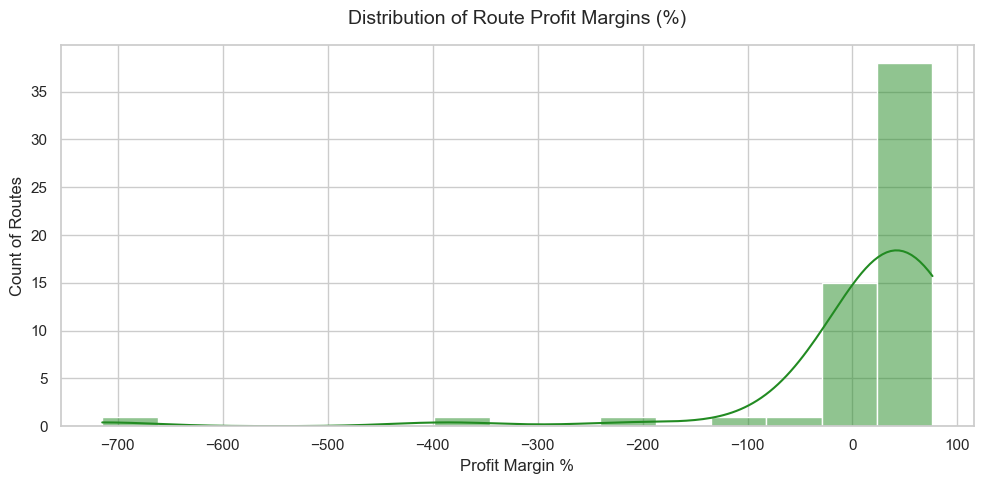

In [62]:
# Set visualization style
sns.set_theme(style="whitegrid")

# Create a standalone figure
plt.figure(figsize=(10, 5))
sns.histplot(df_route_master['profit_margin_pct'], bins=15, kde=True, color='forestgreen')

# Labels and styling
plt.title('Distribution of Route Profit Margins (%)', fontsize=14, pad=15)
plt.xlabel('Profit Margin %', fontsize=12)
plt.ylabel('Count of Routes', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# Which routes are most/least profitable?

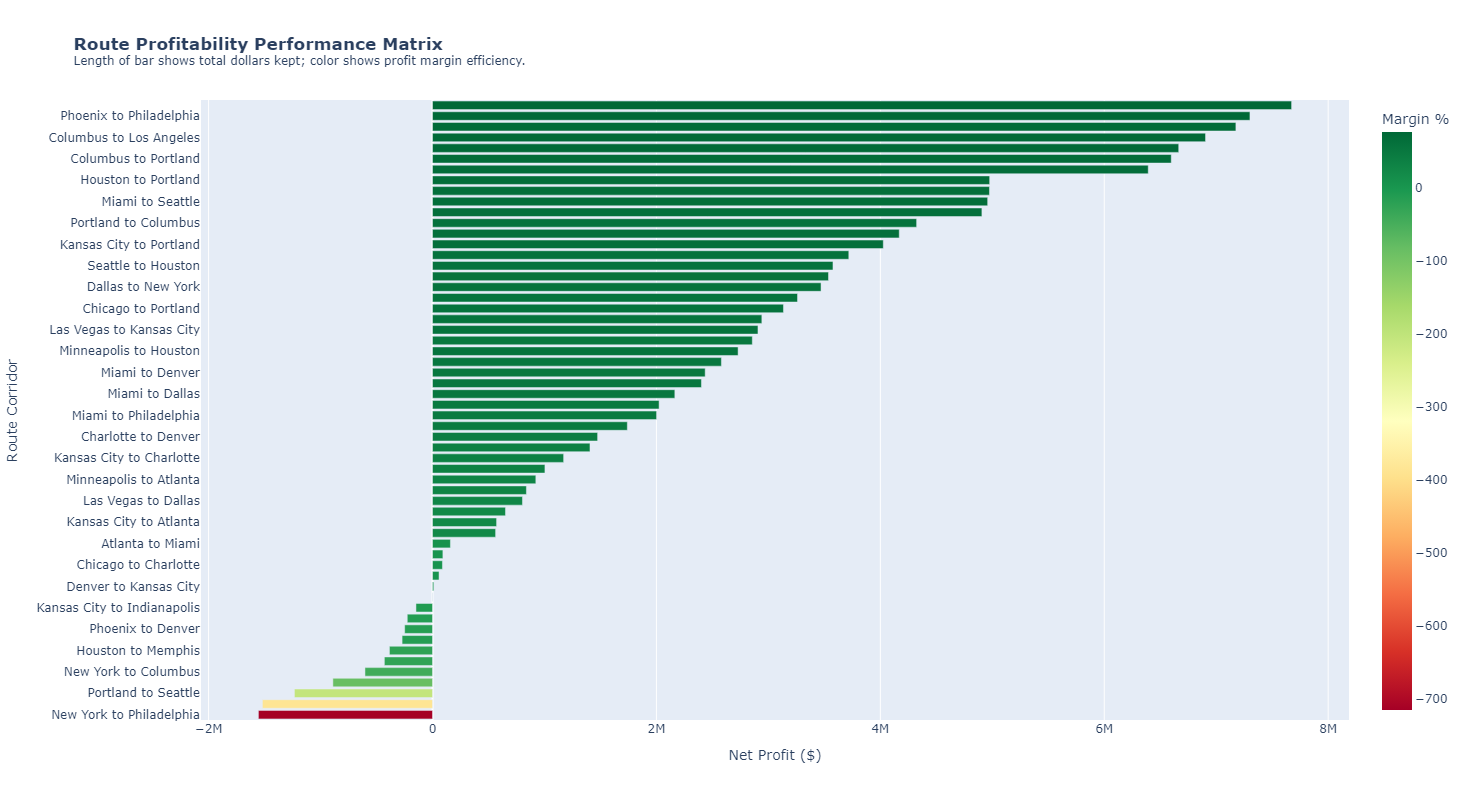

In [42]:
fig_profit = px.bar(
    df_route_master, 
    x='net_profit', 
    y='city_pair', 
    orientation='h',
    color='profit_margin_pct',
    color_continuous_scale='RdYlGn',
    labels={'city_pair': 'Route Corridor', 'net_profit': 'Net Profit ($)', 'profit_margin_pct': 'Margin %'},
    title='<b>Route Profitability Performance Matrix</b><br><sup>Length of bar shows total dollars kept; color shows profit margin efficiency.</sup>',
    height=800
)

# Clean up layout formatting
fig_profit.update_layout(yaxis={'categoryorder':'total ascending'}, coloraxis_showscale=True)
fig_profit.show()

In [ ]:
# Which shipping routes cost the most to run, and why?"

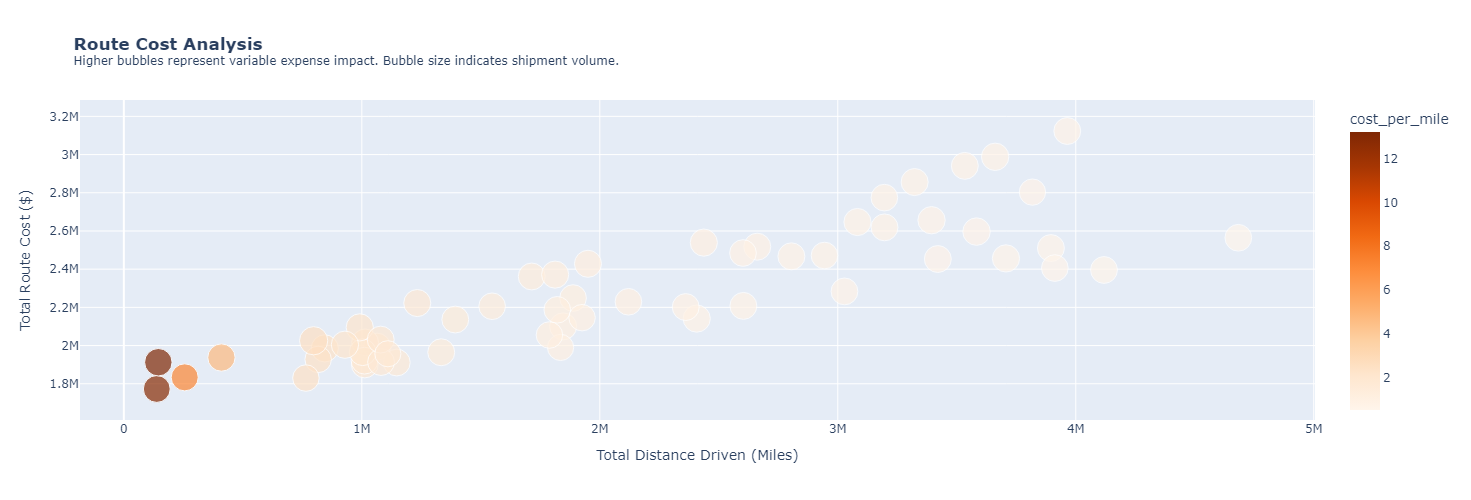

In [66]:
fig_fuel = px.scatter(
    df_route_master,
    x='total_actual_miles',
    y='total_route_cost',
    size='total_loads_moved',
    color='cost_per_mile',
    color_continuous_scale='Oranges',
    hover_name='city_pair',
    height=500,
    labels={
        'total_actual_miles': 'Total Distance Driven (Miles)',
        'total_route_cost': 'Total Route Cost ($)',
        'fuel_cost_per_mile': 'Cost Per Mile ($)',
        'total_loads_moved': 'Volume (Loads)'
    },
    title='<b>Route Cost Analysis</b><br><sup>Higher bubbles represent variable expense impact. Bubble size indicates shipment volume.</sup>'
)
fig_fuel.show()

In [ ]:
# Which lanes give us the best financial buffer per mile?"

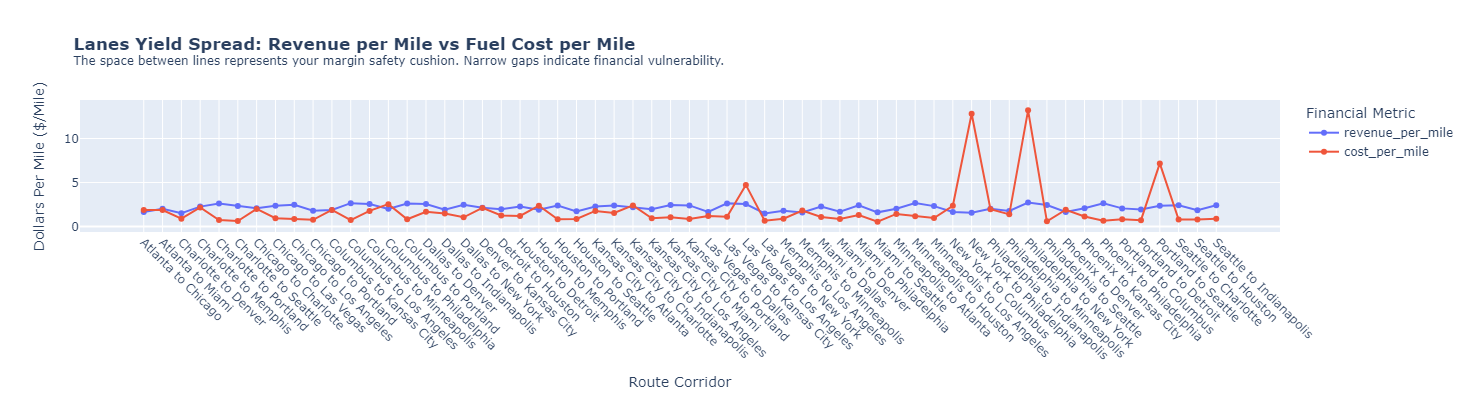

In [70]:
df_sorted_routes = df_route_master.sort_values(by='city_pair')
fig_rates = px.line(
    df_sorted_routes, 
    x='city_pair', 
    y=['revenue_per_mile', 'cost_per_mile'],
    labels={'city_pair': 'Route Corridor', 'value': 'Dollars Per Mile ($/Mile)', 'variable': 'Financial Metric'},
    #labels={'cost_per_mile': 'Cost Per Mile ($/Mile)', 'city_pair': 'Route Corridor', 'revenue_per_mile': 'Revenue Per Mile ($/Mile)'},
    title='<b>Lanes Yield Spread: Revenue per Mile vs Fuel Cost per Mile</b><br><sup>The space between lines represents your margin safety cushion. Narrow gaps indicate financial vulnerability.</sup>',
    markers=True,
    height=400
)

fig_rates.update_xaxes(tickangle=45)
fig_rates.show()